# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregamento

In [2]:
df = pd.read_parquet("/content/dolar.parquet")

print(df.head())
print(df.tail())

         data   valor
0  2016-06-06  3.5098
1  2016-06-07  3.4745
2  2016-06-08  3.3898
3  2016-06-09  3.3817
4  2016-06-10  3.4261
            data   valor
2504  2026-05-28  5.0517
2505  2026-05-29  5.0569
2506  2026-06-01  5.0303
2507  2026-06-02  5.0160
2508  2026-06-03  5.0415


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    2509 non-null   object 
 1   valor   2509 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.3+ KB


In [4]:
df.shape

(2509, 2)

# Linhas vazias

In [5]:
df.isna().sum()

,0
data,0
valor,0


# Convertendo data

In [6]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   data    2509 non-null   datetime64[ns]
 1   valor   2509 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.3 KB


In [8]:
df['data'].isna().sum()

np.int64(0)

# Cobertura temporal

In [9]:
print("Data inicial: ", df['data'].min())
print("Data final: ", df['data'].max())

Data inicial:  2016-06-06 00:00:00
Data final:  2026-06-03 00:00:00


# Duplicatas

In [10]:
df.duplicated().sum()

np.int64(0)

# Valores impossiveis

In [12]:
valores_invalidos = df.loc[df['valor'] <= 0]

valores_invalidos

,data,valor


# Estatisticas descritivas

In [13]:
df.describe()

,data,valor
count,2509,2509.000000
mean,2021-06-03 12:15:12.554802688,4.656981
min,2016-06-06 00:00:00,3.051000
25%,2018-12-05 00:00:00,3.819300
50%,2021-06-07 00:00:00,5.017800
75%,2023-12-04 00:00:00,5.369800
max,2026-06-03 00:00:00,6.208600
std,NaN,0.897492


# Inspeção visual

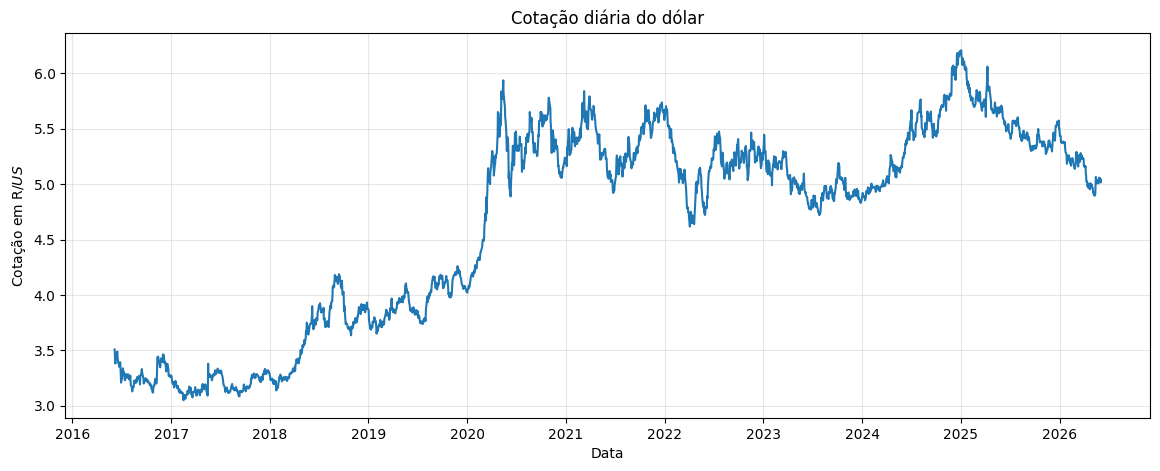

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["data"],
    df["valor"]
)

ax.set_title("Cotação diária do dólar")
ax.set_xlabel("Data")
ax.set_ylabel("Cotação em R$/US$")
ax.grid(alpha=0.3)

plt.show()

# Referencia Semanal

In [15]:
df['semana'] = df['data'].dt.to_period('W-FRI').dt.end_time.dt.normalize()

In [16]:
df.head()

,data,valor,semana
0,2016-06-06,3.5098,2016-06-10
1,2016-06-07,3.4745,2016-06-10
2,2016-06-08,3.3898,2016-06-10
3,2016-06-09,3.3817,2016-06-10
4,2016-06-10,3.4261,2016-06-10


# Agregações semanais

In [18]:
dolar_semanal = (
    df
    .sort_values("data")
    .groupby("semana", as_index=False)
    .agg(
        dolar_medio_semana=(
            "valor",
            "mean"
        ),
        dolar_fechamento_semana=(
            "valor",
            'last'
        ),
        dolar_min_semana=(
            "valor",
            "min"
        ),
        dolar_max_semana=(
            "valor",
            "max"
        ),
        dolar_desvio_padrao_semana=(
            "valor",
            "std"
        ),
        qtd_dias_dolar=(
            "data",
            "nunique"
        ),
    )
)

# Validando tabela semanal

In [19]:
dolar_semanal.head()

,semana,dolar_medio_semana,dolar_fechamento_semana,dolar_min_semana,dolar_max_semana,dolar_desvio_padrao_semana,qtd_dias_dolar
0,2016-06-10,3.43638,3.4261,3.3817,3.5098,0.055020,5
1,2016-06-17,3.46832,3.4372,3.4372,3.4904,0.022340,5
2,2016-06-24,3.37840,3.3772,3.3533,3.3897,0.014859,5
3,2016-07-01,3.28064,3.2298,3.2098,3.3934,0.077167,5
4,2016-07-08,3.29964,3.2968,3.2480,3.3388,0.034989,5


In [20]:
dolar_semanal.tail()

,semana,dolar_medio_semana,dolar_fechamento_semana,dolar_min_semana,dolar_max_semana,dolar_desvio_padrao_semana,qtd_dias_dolar
517,2026-05-08,4.925440,4.8999,4.8999,4.9587,0.021419,5
518,2026-05-15,4.950620,5.0654,4.8973,5.0654,0.072873,5
519,2026-05-22,5.019780,5.0140,5.0077,5.0378,0.013420,5
520,2026-05-29,5.038960,5.0569,5.0072,5.0579,0.023295,5
521,2026-06-05,5.029267,5.0415,5.0160,5.0415,0.012781,3


In [21]:
dolar_semanal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   semana                      522 non-null    datetime64[ns]
 1   dolar_medio_semana          522 non-null    float64       
 2   dolar_fechamento_semana     522 non-null    float64       
 3   dolar_min_semana            522 non-null    float64       
 4   dolar_max_semana            522 non-null    float64       
 5   dolar_desvio_padrao_semana  522 non-null    float64       
 6   qtd_dias_dolar              522 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 28.7 KB


In [22]:
dolar_semanal.isna().sum()

,0
semana,0
dolar_medio_semana,0
dolar_fechamento_semana,0
dolar_min_semana,0
dolar_max_semana,0
dolar_desvio_padrao_semana,0
qtd_dias_dolar,0


In [23]:
dolar_semanal.to_parquet("dolar_semanal.parquet")